### https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification

- fixed acidity: most acids involved with wine or fixed or nonvolatile (do not evaporate readily). Acidity is a characteristic determined by the total sum of acids that a sample contains. We can quantify the set of all of them in an undifferentiated way (total acidity) or in a grouped way (fixed acidity and volatile acidity). Fixed acidity corresponds to the set of low volatility organic acids such as malic, lactic, tartaric or citric acids and is inherent to the characteristics of the sample.
- volatile acidity: the amount of acetic acid in wine, which at too high of levels can lead to an unpleasant, vinegar taste. Volatile acidity corresponds to the set of short chain organic acids that can be extracted from the sample by means of a distillation process: formic acid, acetic acid, propionic acid and butyric acid.
- citric acid: found in small quantities, citric acid can add 'freshness' and flavor to wines. Citric acid is a colorless weak organic acid. It occurs naturally in citrus fruits. In biochemistry, it is an intermediate in the citric acid cycle, which occurs in the metabolism of all aerobic organisms.
- residual sugar: the amount of sugar remaining after fermentation stops, it's rare to find wines with less than 1 gram/liter. Residual sugar refers to the sugars left unfermented in a finished wine. It is measured by grams of sugar per litre (g/l). The amount of residual sugar affects a wine's sweetness and, in the EU, the RS level is linked to specific labelling terms.
- chlorides: the amount of salt in the wine. The higher extraction of chloride during red winemaking is due to the ions extracted from skins during fermentation. Therefore, red juice should have no more than 356mg/L chloride ions so that finished wine does not exceed the maximum legal level of 606mg/L chloride(356mg/L in red juice x 1.7 = 606).
- free sulfur dioxide: the free form of SO2 exists in equilibrium between molecular SO2 (as a dissolved gas) and bisulfite ion. What is free sulphur dioxide in wine? The free sulfites are those available to react and thus exhibit both germicidal and antioxidant properties. The bound sulfites are those that have reacted (both reversibly and irreversibly) with other molecules within the wine medium. The sum of the free and bound sulfites defines the total sulfite concentration.
- total sulfur dioxide: amount of free and bound forms of S02; in low concentrations, SO2 is mostly undetectable in wine, but at free SO2. Simply put, Total Sulfur Dioxide (TSO2) is the portion of SO2 that is free in the wine plus the portion that is bound to other chemicals in the wine such as aldehydes, pigments, or sugars.
- density: the density of water is close to that of water depending on the percent alcohol and sugar content. How do you measure the density of wine? A hydrometer is an instrument used to measure liquid density. It is a sealed glass tube with a weighted bulb at one end, winemakers use this instrument to measure density of juice, fermenting wine and completed wine in relation to pure water. This ratio is called specific gravity (SG).
- pH: describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic); most wines are between 3-4. What is a high pH in wine? Wines which have higher pH values (>3.65) have a series of potential challenges during vinification and aging. First, high pH wines have an increased chance of microbial spoilage. Traditionally, sulfur dioxide (often in the form of potassium metabisulfite) is used to keep wines stable during aging.
- sulphates: a wine additive which can contribute to sulfur dioxide gas (S02) levels, wich acts as an antimicrobial. Wine sulfites are naturally occurring at low levels in all wines, and are one of the thousands of chemical by-products created during the fermentation process. However, sulfites are also added by the winemaker to preserve and protect the wine from bacteria and yeast-laden invasions. For some, sulfur allergies may be associated with headaches and stuffy sinuses after a glass or two of wine. It is a a wine additive which can contribute to sulfur dioxide gas (S02) levels, wich acts as an antimicrobial.
- Alcohol: this is the percent alcohol content of the wine
- quality: output variable (based on sensory data, score between 3 and 8).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv


In [3]:
os.getcwd()

'/kaggle/working'

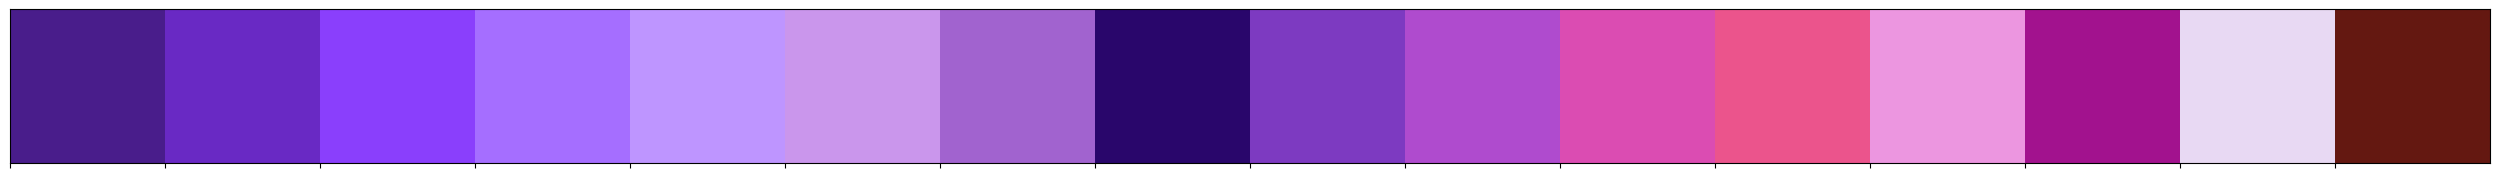

In [4]:
purple = ['#491D8B', '#6929C4', '#8A3FFC', '#A56EFF',
          '#BE95FF', '#CA96EC', '#A163CF', '#29066B',
          '#7D3AC1', '#AF4BCE', '#DB4CB2', '#EB548C',
          '#EC96E0', '#A2128E', '#E8D9F3', '#641811']

sns.palplot(purple, size = 2)

## Load Dataset

In [5]:
red_wine_df = pd.read_csv("../input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv")
red_wine_df.shape

(1599, 12)

In [6]:
df = red_wine_df.copy()
df.head(n=10).style.background_gradient(cmap='Purples_r')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,5
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,5
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,6
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5
5,7.400000,0.660000,0.000000,1.800000,0.075000,13.000000,40.000000,0.997800,3.510000,0.560000,9.400000,5
6,7.900000,0.600000,0.060000,1.600000,0.069000,15.000000,59.000000,0.996400,3.300000,0.460000,9.400000,5
7,7.300000,0.650000,0.000000,1.200000,0.065000,15.000000,21.000000,0.994600,3.390000,0.470000,10.000000,7
8,7.800000,0.580000,0.020000,2.000000,0.073000,9.000000,18.000000,0.996800,3.360000,0.570000,9.500000,7
9,7.500000,0.500000,0.360000,6.100000,0.071000,17.000000,102.000000,0.997800,3.350000,0.800000,10.500000,5


## Basic Information about dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


It turns out that the dataset does not have null values. The dataset consists of 1599 rows and 12 columns. The data type of all variables are numeric. 

In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
df.describe().T.style.background_gradient(cmap="magma")

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


In [10]:
# from markupsafe import escape
# !pip install pandas-profiling
# import pandas_profiling

# profiling = pandas_profiling.ProfileReport(df)
# profiling

In [11]:
"Totally there are {} null values in the dataset".format(df.isnull().sum().sum())

'Totally there are 0 null values in the dataset'

In [12]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [13]:
df.rename(columns = {
    "fixed acidity": "fixed_acidity", "volatile acidity": "volatile_acidity", 
    "citric acid": "citric_acid", "residual sugar": "residual_sugar",
    "chlorides": "chlorides", "free sulfur dioxide": "free_sulfur_dioxide",
    "total sulfur dioxide": "total_sulfur_dioxide"
}, inplace = True)

## EDA && Data Visualization

EDA 1. Histogram

Text(0.5, 1.0, 'Distribution of Citric Acid')

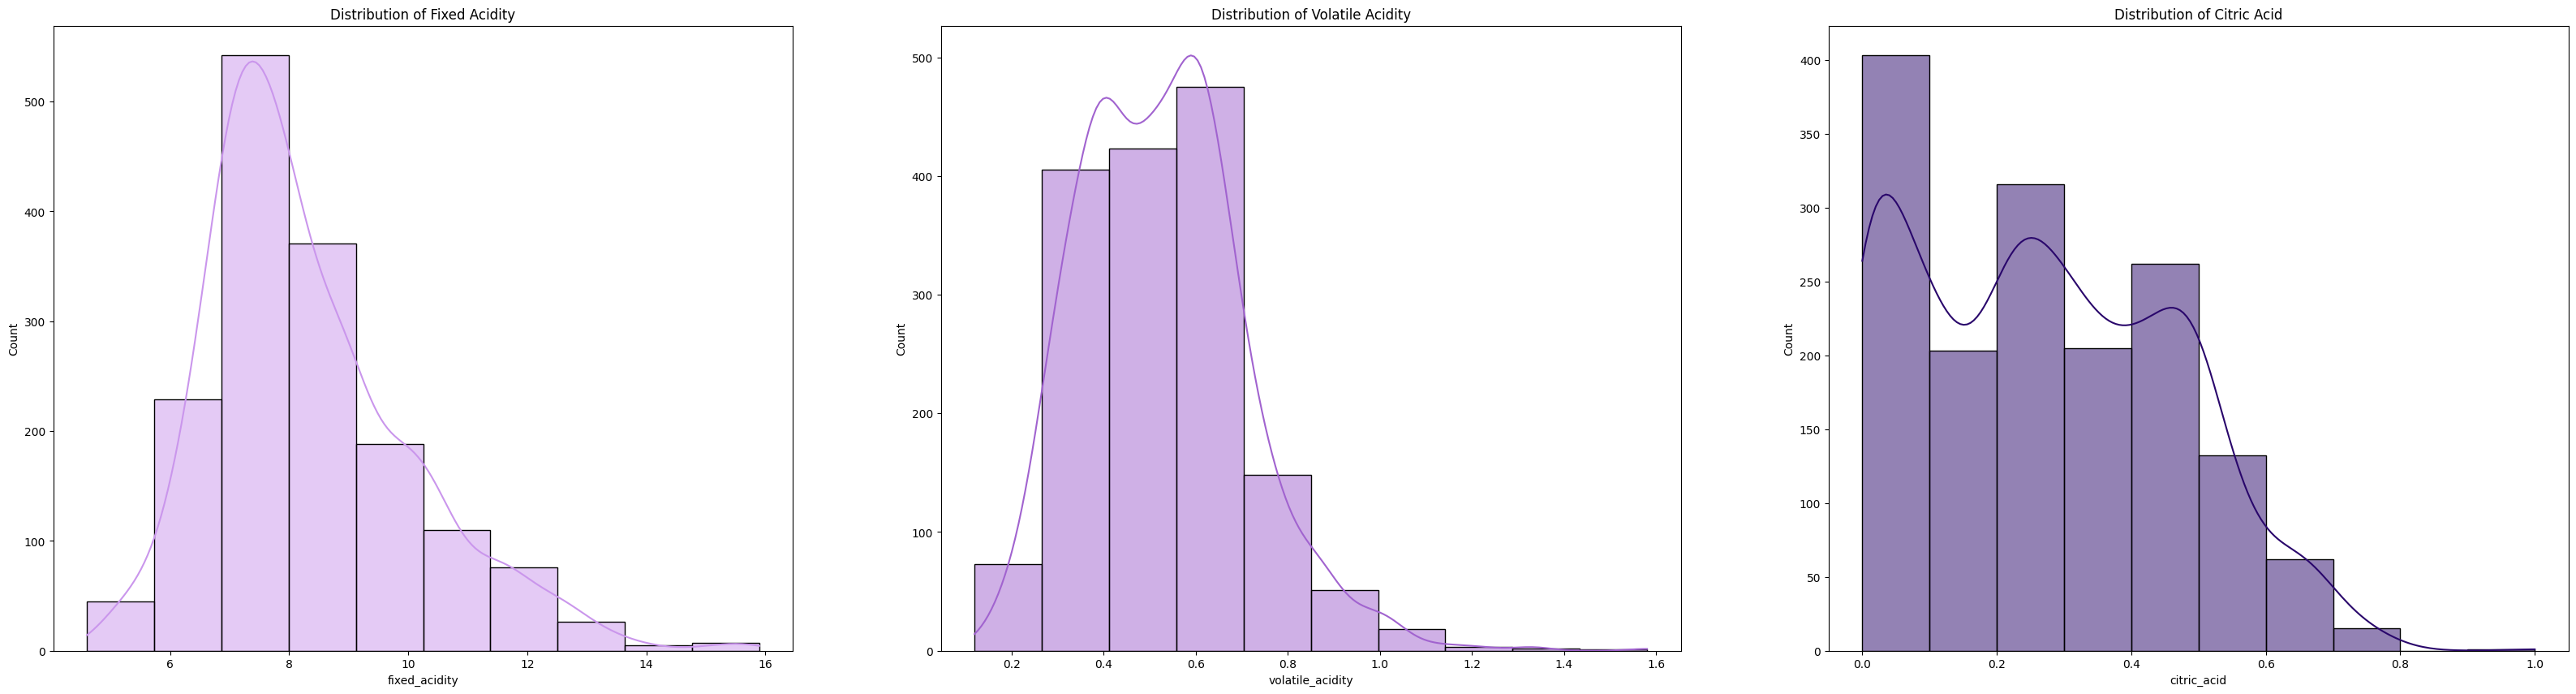

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(40, 10))

sns.histplot(ax=axes[0], x=df.fixed_acidity, bins=10, kde=True, cbar=True, color="#CA96EC").set_title("Distribution of Fixed Acidity")
sns.histplot(ax=axes[1], x=df.volatile_acidity, bins=10, kde=True, cbar=True, color="#A163CF").set_title("Distribution of Volatile Acidity")
sns.histplot(ax=axes[2], x=df.citric_acid, bins=10, kde=True, cbar=True, color="#29066B").set_title("Distribution of Citric Acid")

Analyzing the graphs here, it turns out that the values of the variable 'fixed_acidity' are relatively normally distributed (but a bit left skewed). But there are two peaks in the distributions of other 'volatile_acidity' and 'citric_acid' variables.

Text(0.5, 1.0, 'Distribution of Alcohol')

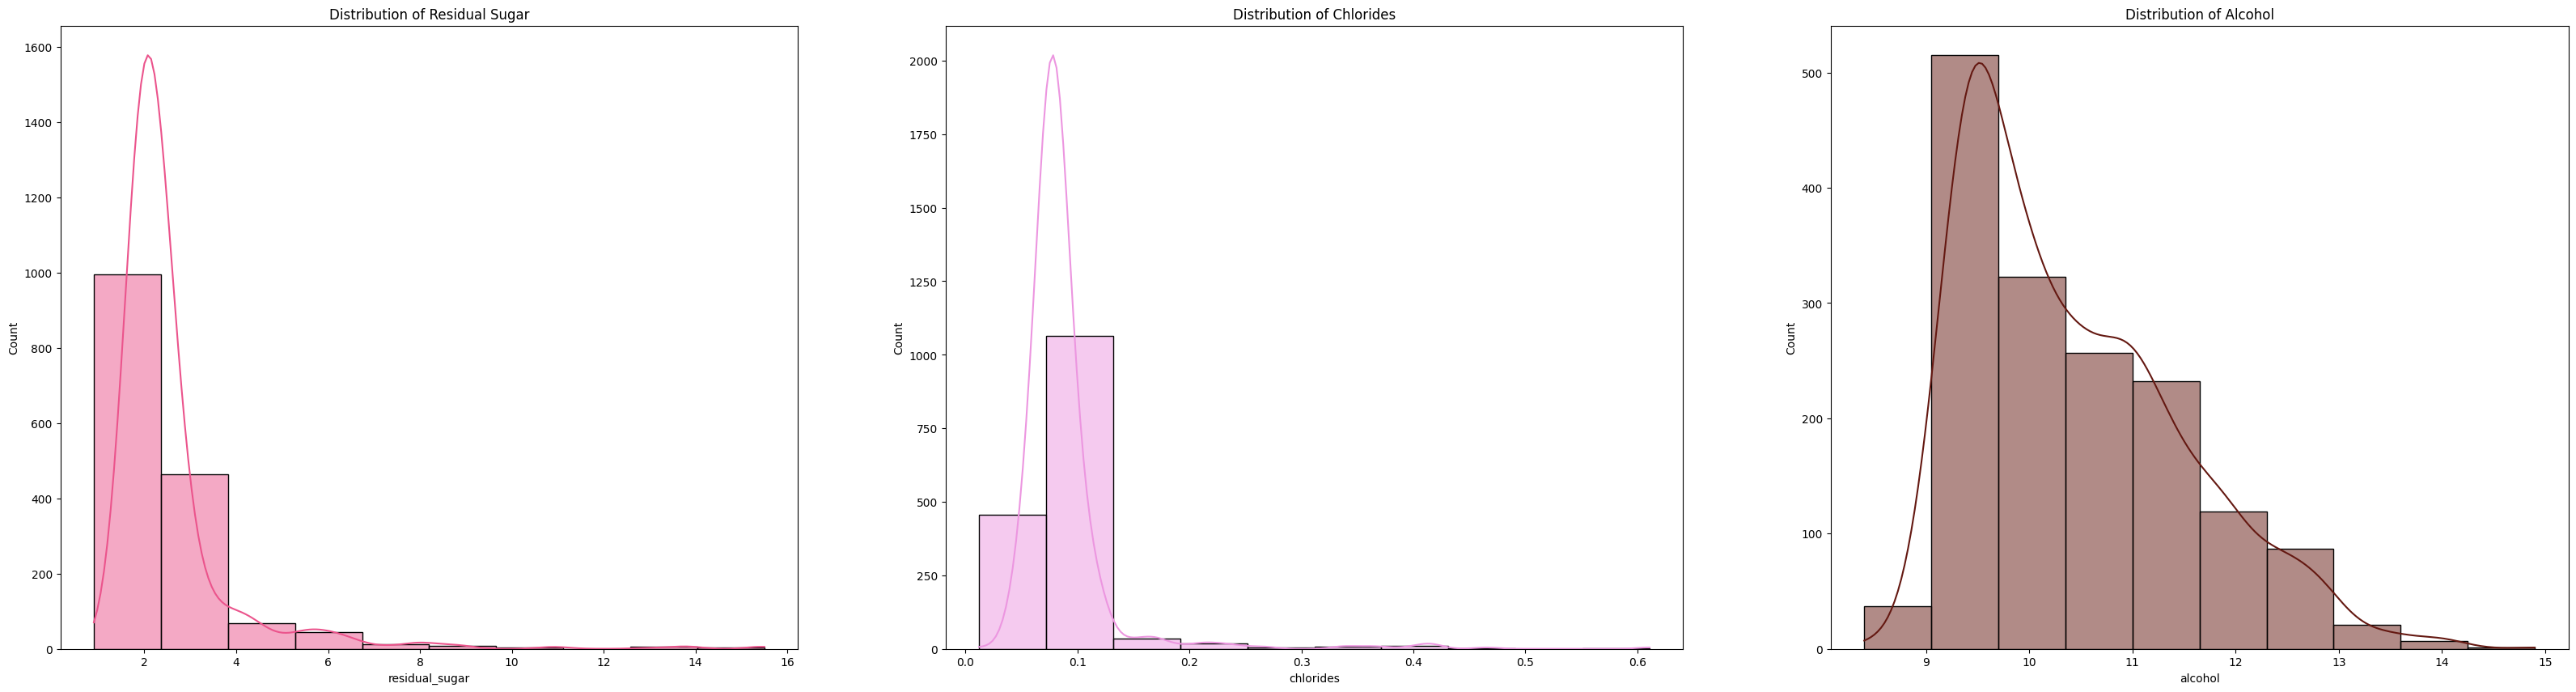

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(40, 10))

sns.histplot(ax=axes[0], x=df.residual_sugar, bins=10, kde=True, cbar=True, color="#EB548C").set_title("Distribution of Residual Sugar")
sns.histplot(ax=axes[1], x=df.chlorides, bins=10, kde=True, cbar=True, color="#EC96E0").set_title("Distribution of Chlorides")
sns.histplot(ax=axes[2], x=df.alcohol, bins=10, kde=True, cbar=True, color="#641811").set_title("Distribution of Alcohol")

Analyzing the graphs here, it turns out that the distributions of these variables are not normal

EDA 2. Pairplot

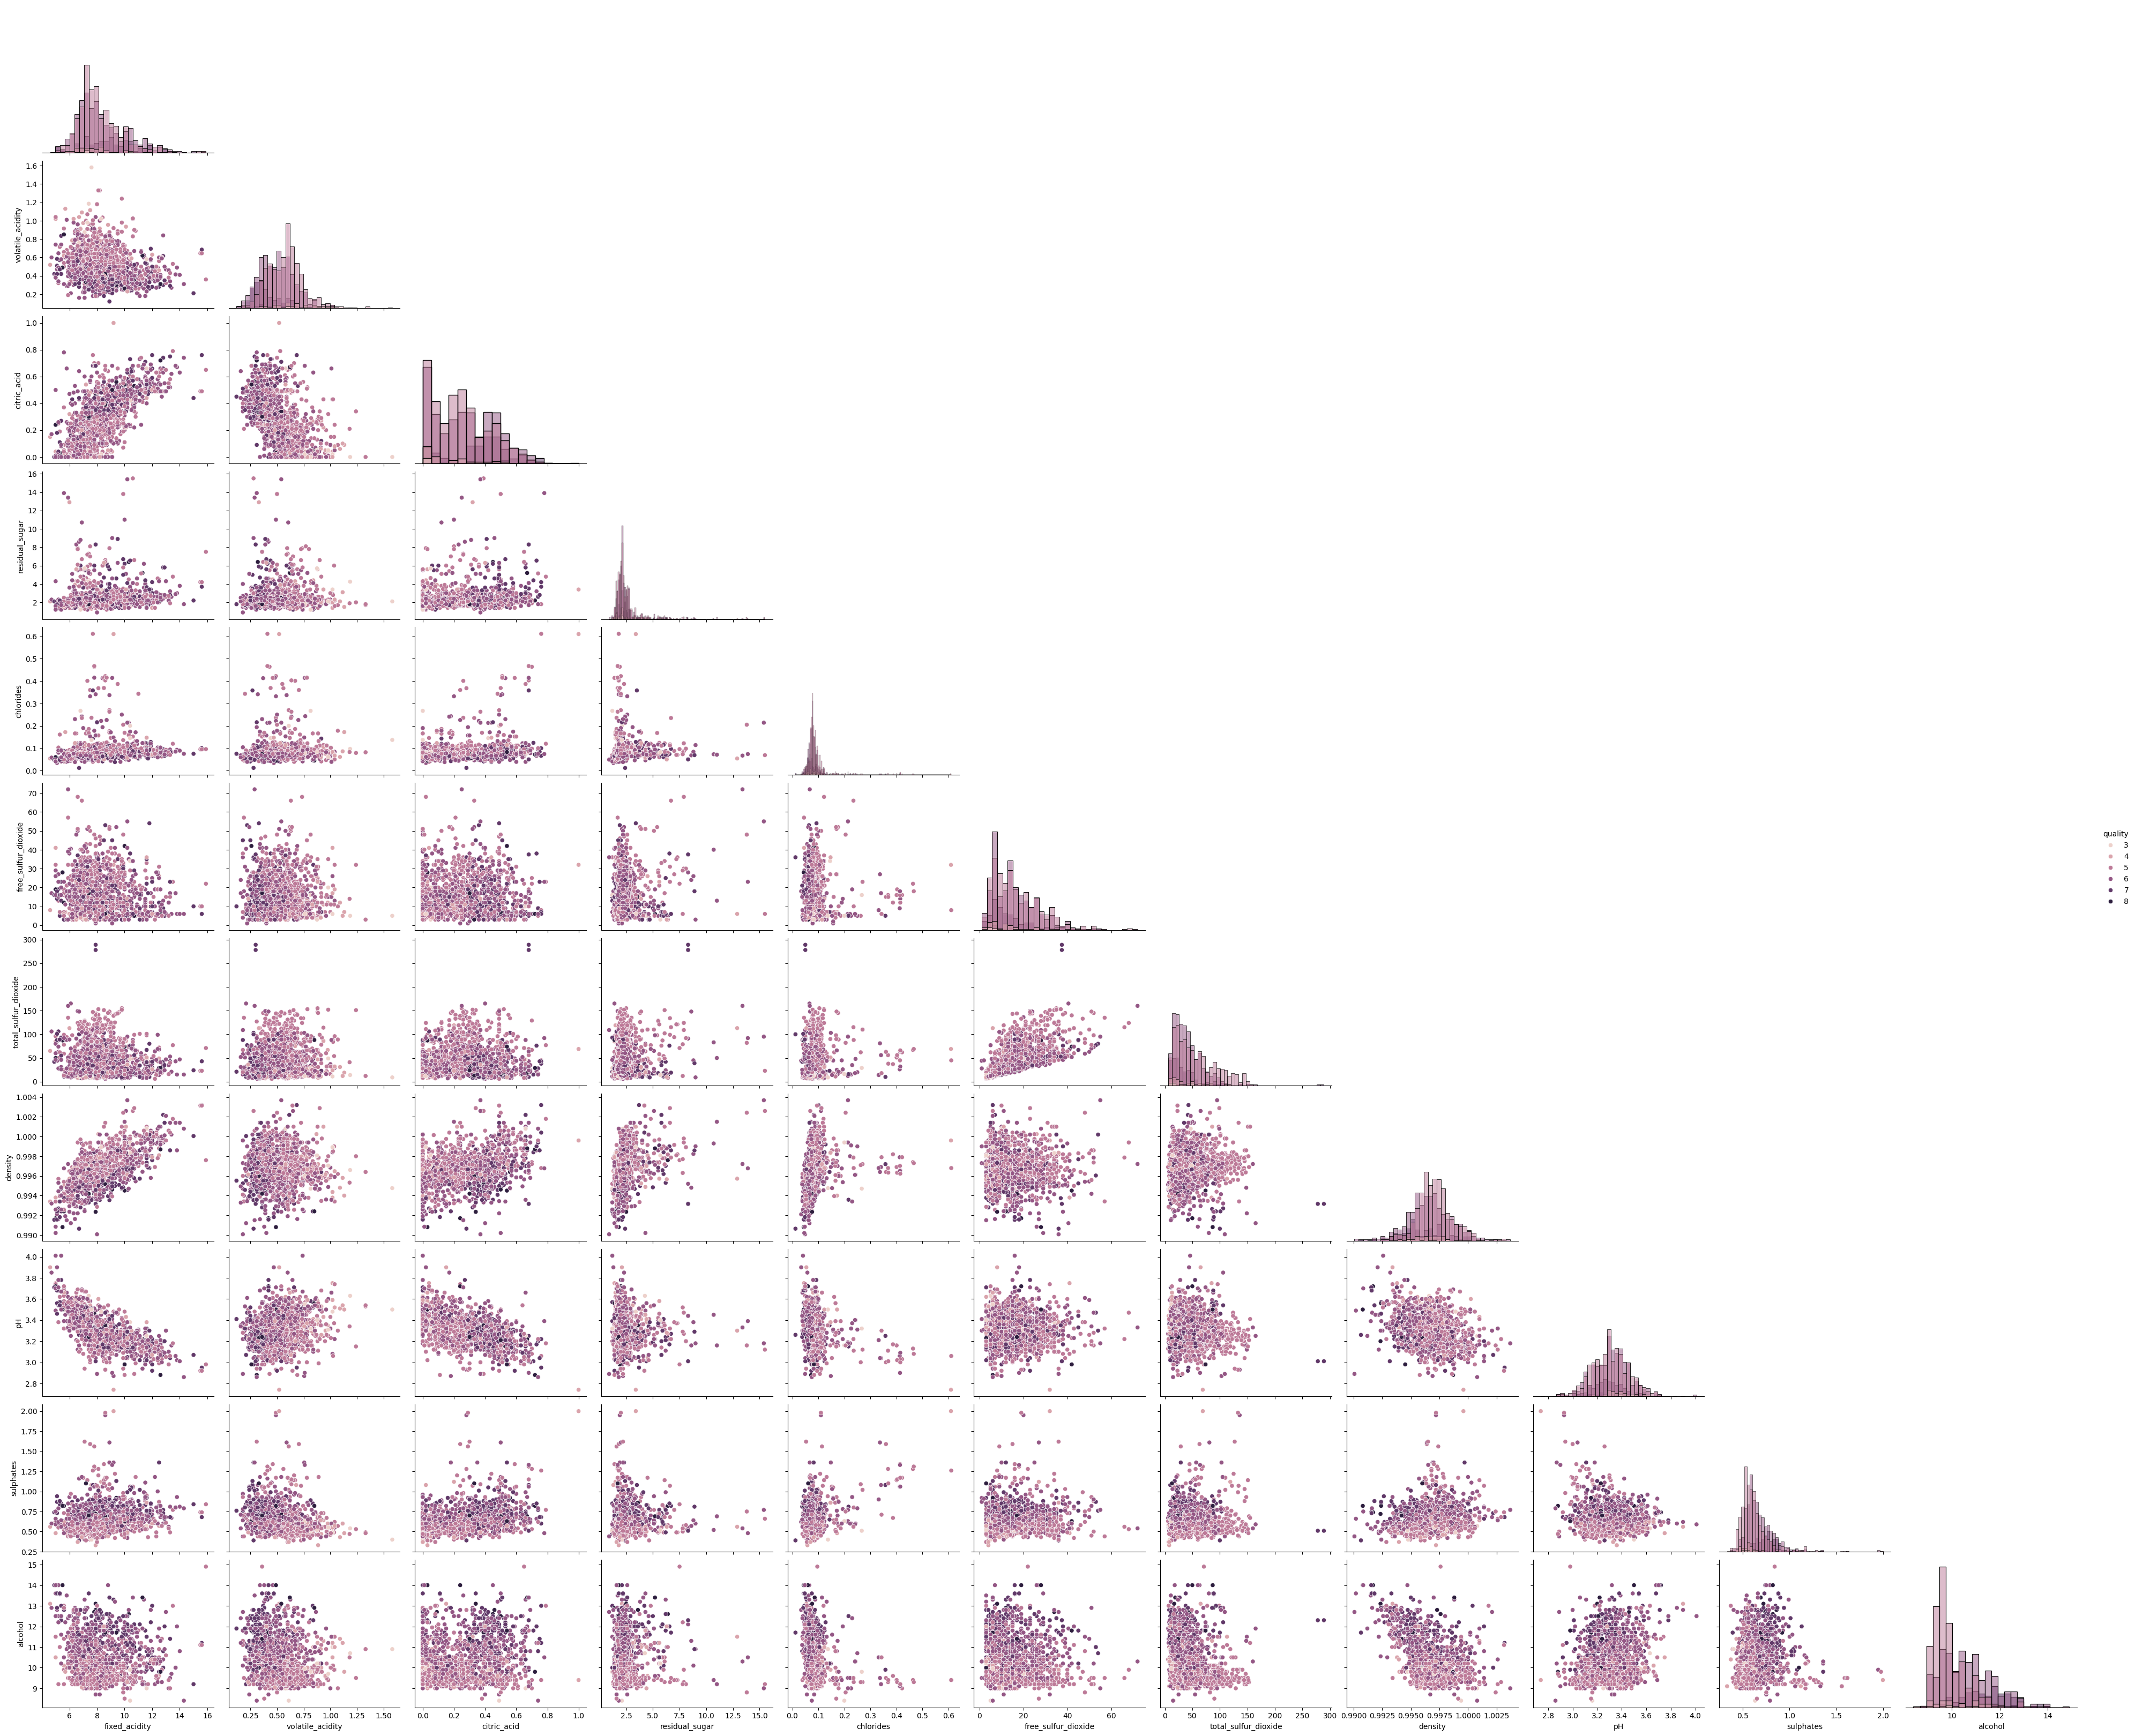

In [16]:
sns.pairplot(df, diag_kind="hist", hue="quality", height=3, aspect=1.2, corner=True)

We see here that there is correlation between some variables. And this is what we don't want. This problem is called 'multicollinearity'

In [17]:
df.corr(numeric_only=True).style.background_gradient(cmap="magma")

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
fixed_acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile_acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric_acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual_sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free_sulfur_dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total_sulfur_dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


| Correlation (r) | Meaning                       |
| --------------: | ----------------------------- |
|            +1.0 | Perfect positive correlation  |
|    +0.8 to +1.0 | Strong positive correlation   |
|    +0.5 to +0.8 | Moderate positive correlation |
|    +0.3 to +0.5 | Weak positive correlation     |
|               0 | No linear correlation         |
|    -0.3 to -0.5 | Weak negative correlation     |
|    -0.5 to -0.8 | Moderate negative correlation |
|    -0.8 to -1.0 | Strong negative correlation   |
|            -1.0 | Perfect negative correlation  |


Multi-Collinear Independent Features  
Multicollinearity means that two or more independent variables are highly correlated. They contain similar information, which can make models like linear regression unstable.  

| Variables                                  | Correlation |
| ------------------------------------------ | ----------: |
| fixed_acidity ↔ pH                         |  **-0.683** |
| fixed_acidity ↔ citric_acid                |   **0.672** |
| fixed_acidity ↔ density                    |   **0.668** |
| free_sulfur_dioxide ↔ total_sulfur_dioxide |   **0.668** |

A common rule of thumb is:

|r| < 0.7 → Usually acceptable  
0.7 ≤ |r| < 0.9 → Investigate  
|r| ≥ 0.9 → Strong candidate for removing one of the variables

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop(columns='quality')

vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

print(vif.sort_values("VIF", ascending=False))

# Interpretation of VIF:

# VIF ≈ 1 → No multicollinearity
# 1–5 → Acceptable
# 5–10 → High, investigate
# >10 → Severe multicollinearity

                 Feature          VIF
7                density  1479.287209
8                     pH  1070.967685
10               alcohol   124.394866
0          fixed_acidity    74.452265
9              sulphates    21.590621
1       volatile_acidity    17.060026
2            citric_acid     9.183495
4              chlorides     6.554877
6   total_sulfur_dioxide     6.519699
5    free_sulfur_dioxide     6.442682
3         residual_sugar     4.662992


EDA 3. Scatterplot

Text(0.5, 1.0, "Relationship between 'density' and 'quality'")

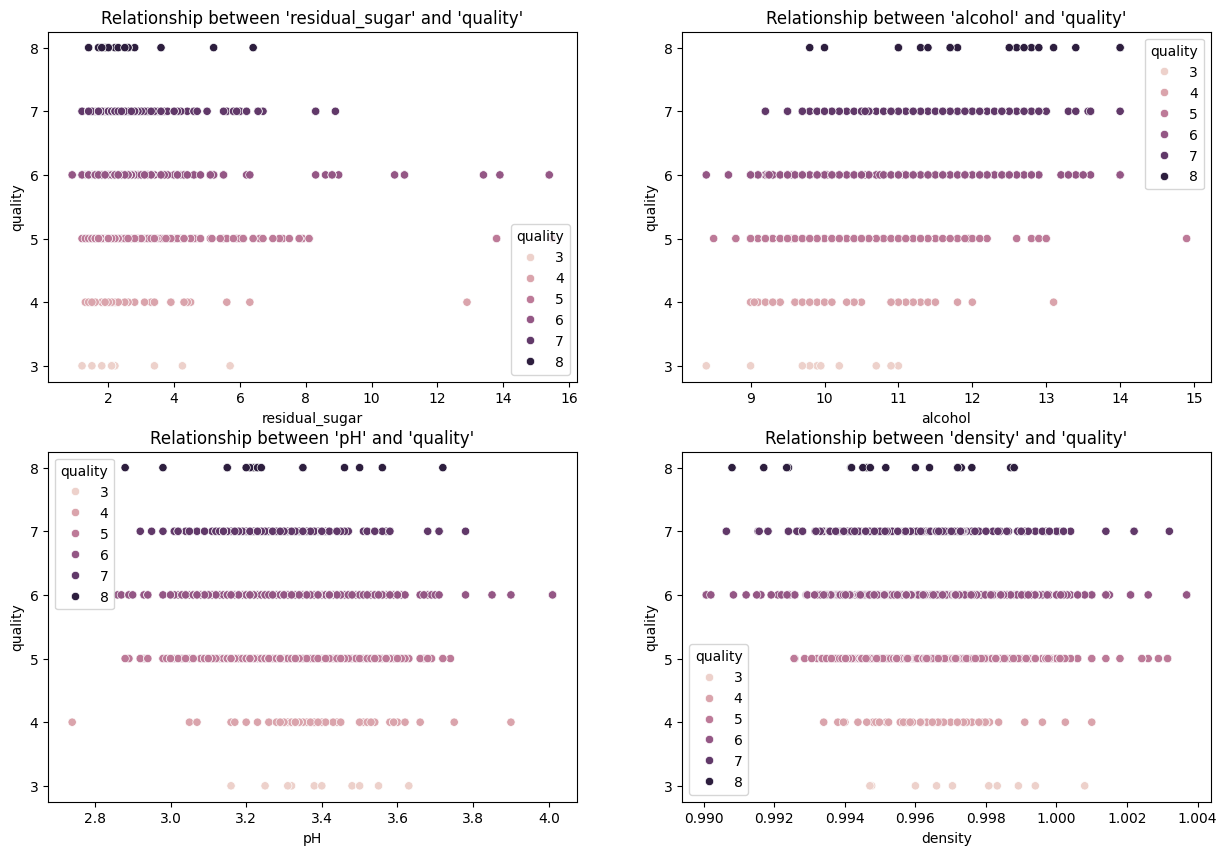

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.scatterplot(ax=axes[0], x="residual_sugar", y="quality", hue="quality", data=df).set_title("Relationship between 'residual_sugar' and 'quality'")
sns.scatterplot(ax=axes[1], x="alcohol", y="quality", hue="quality", data=df).set_title("Relationship between 'alcohol' and 'quality'")
sns.scatterplot(ax=axes[2], x="pH", y="quality", hue="quality", data=df).set_title("Relationship between 'pH' and 'quality'")
sns.scatterplot(ax=axes[3], x="density", y="quality", hue="quality", data=df).set_title("Relationship between 'density' and 'quality'")

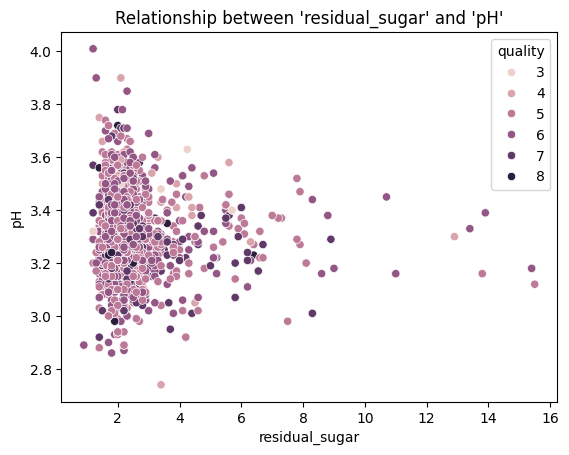

In [20]:
sns.scatterplot(x="residual_sugar", y="pH", hue = "quality", data = df).set_title("Relationship between 'residual_sugar' and 'pH'");

As it can be seen there is not correlation between 'residual_sugar' and 'pH' variables

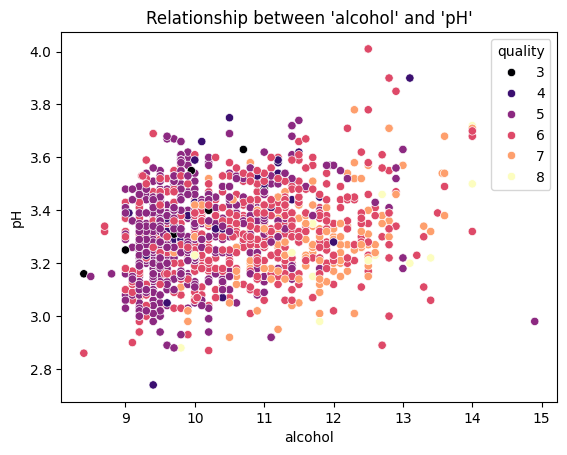

In [21]:
sns.scatterplot(x="alcohol", y="pH", hue = "quality", palette="magma", data = df).set_title("Relationship between 'alcohol' and 'pH'");

As it can be seen there is not correlation between 'alcohol' and 'pH' variables

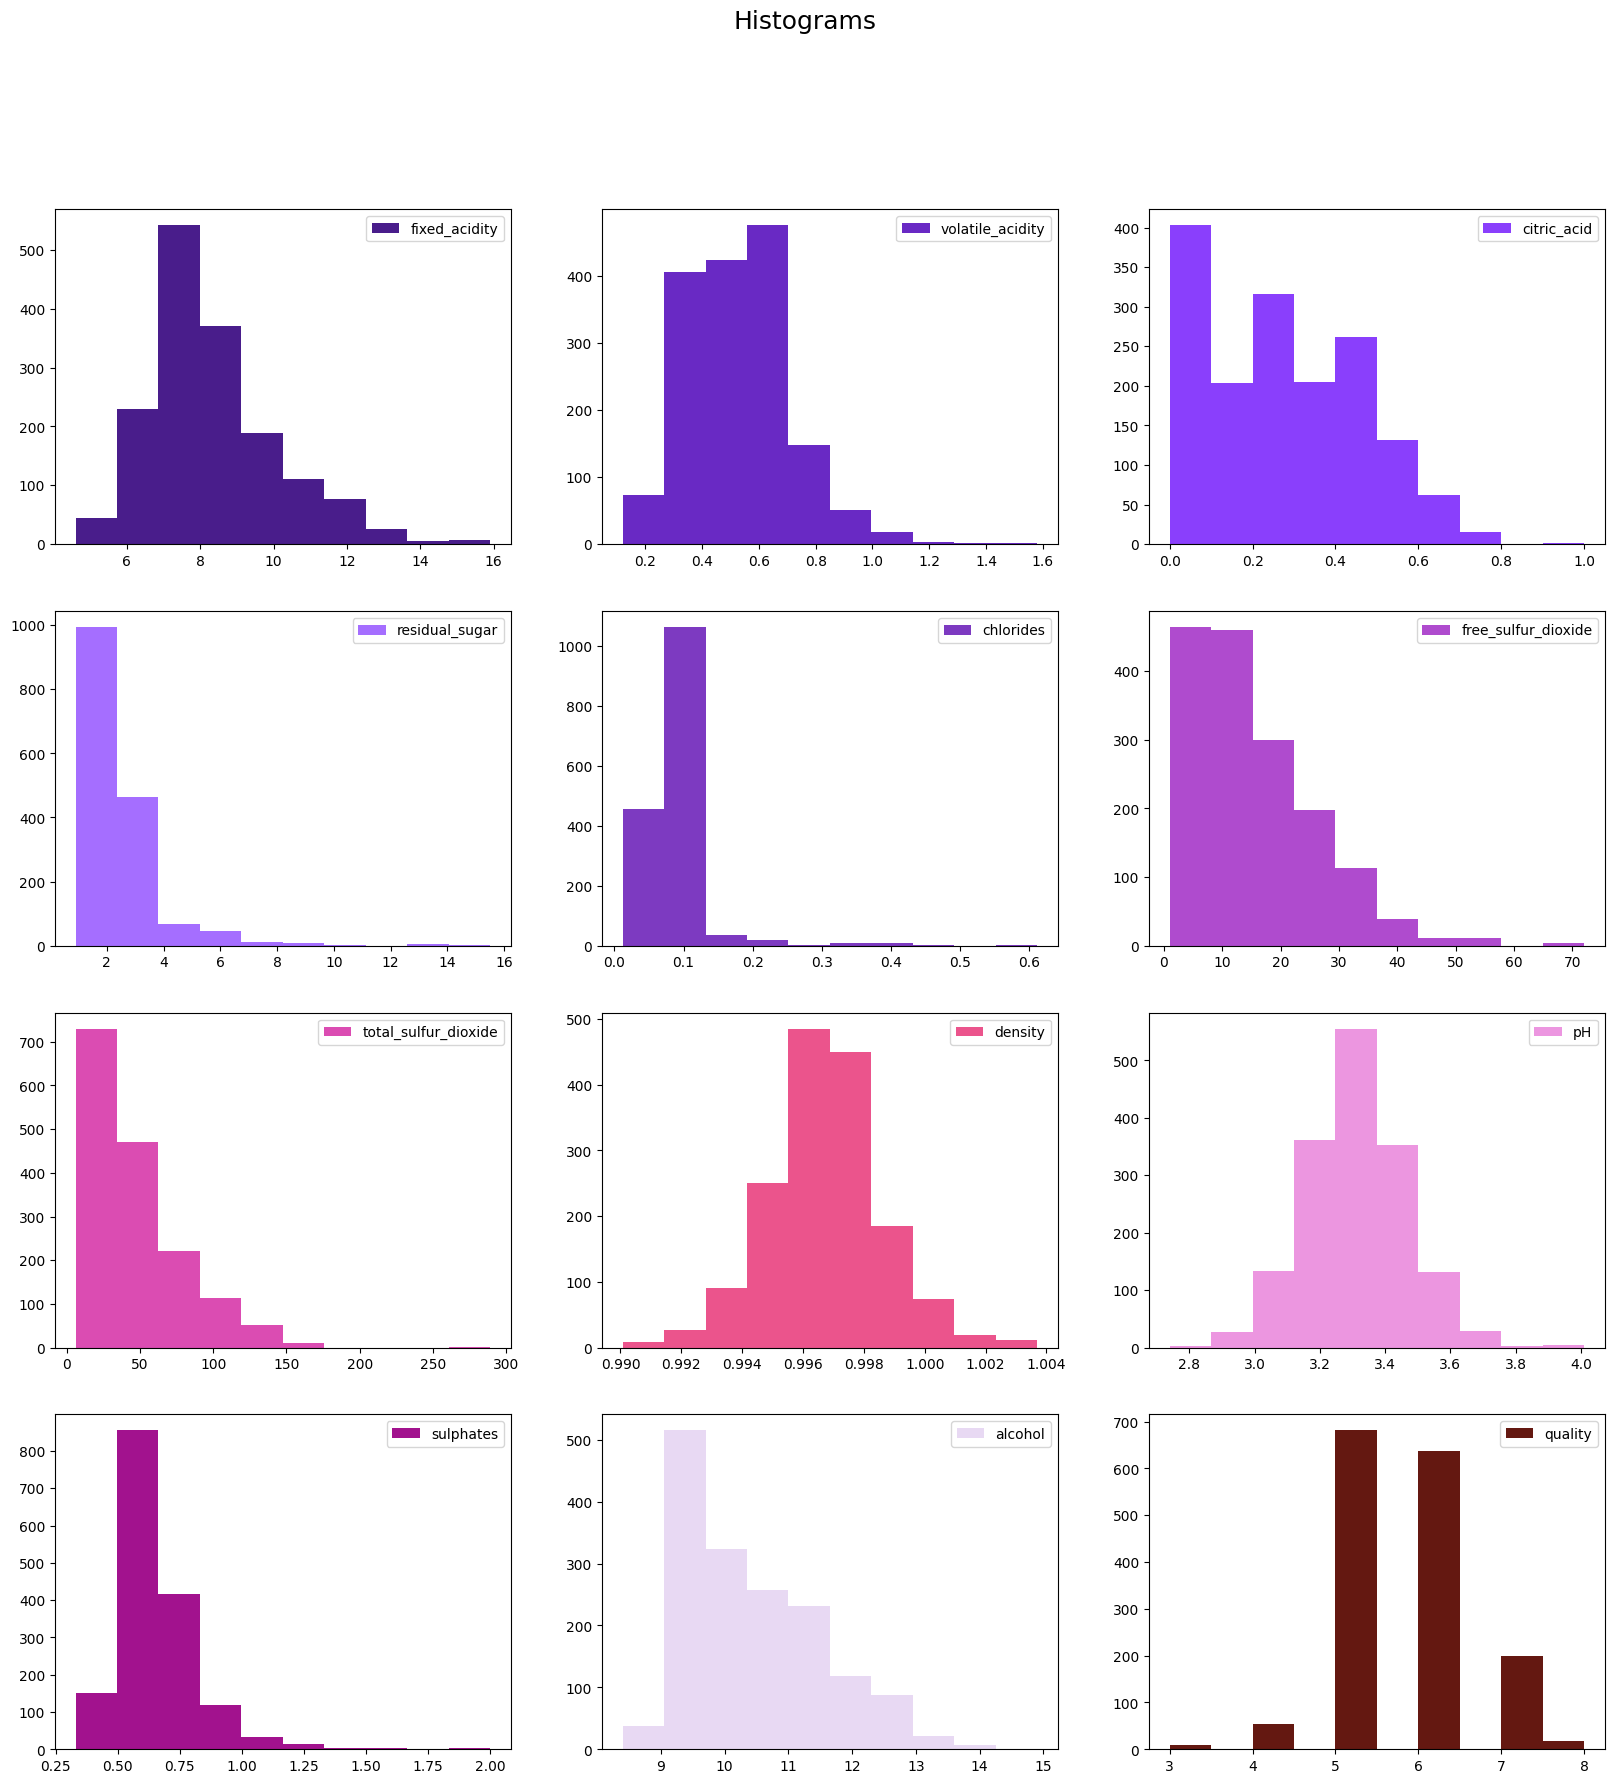

In [22]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

colors = ['#491D8B', '#6929C4', '#8A3FFC', 
          '#A56EFF', '#7D3AC1', '#AF4BCE', 
          '#DB4CB2', '#EB548C', '#EC96E0', 
          '#A2128E', '#E8D9F3', '#641811']
for index, column in enumerate(df.columns):
    ax = axes[index]
    ax.hist(df[column], color=colors[index], label=column, bins=10)
    ax.legend(loc="best")
plt.suptitle("Histograms", size=18)
plt.show()

Here we see the distributions of values of all variables. As it can be seen from the charts, the values of 'pH' and "density" variables are relatively normally distributed.
Most of the values ​​of the "fixed_acidity" variable are in the range of 7 - 8;  
Most of the values ​​of the "volatile_acidity" variable are in the range of 0.4 - 0.7;  
Most values ​​of the "citric_acid" variable are in the range of 0.0 - 0.1;  
Most of the values ​​of the "residual_sugar" variable are in the range of 1 - 2.5;  
Most of the values ​​of the "chlorides" variable are in the range of 0.085 - 0.15;  
Most values ​​of the "free_sulfur_dioxide" variable are in the range 0 - 15;  
Most values ​​of the "total_sulfur_dioxide" variable are in the range 0 - 30;  
Most of the values ​​of the "density" variable are in the range of 0.996 - 0.998;  
Most of the values ​​of the "pH" variable are in the range of 3.2 - 3.4;  
Most of the values ​​of the "sulphates" variable are in the range of 0.50 - 0.75;  
Most of the values ​​of the "alcohol" variable are in the range of 9 - 10;  
Most values ​​of the "quality" variable are 5 and 6.

EDA 4. Smooth Kernel Density with Marginal Histograms  
In the density graphs below, we will observe the relationships between some variables. In addition, we will also use marginal histograms.

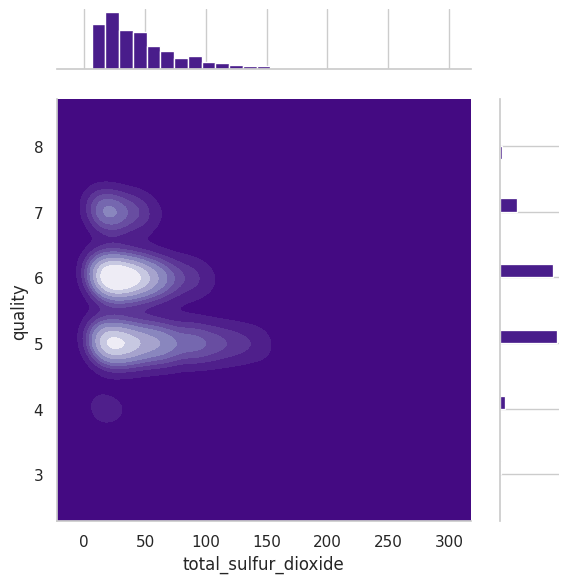

In [23]:
sns.set_theme(style = "whitegrid")
g = sns.JointGrid(data = df, x = "total_sulfur_dioxide", y = "quality", space = 0.5)
g.plot_joint(sns.kdeplot, fill = True, thresh = 0, cmap = "Purples_r")
g.plot_marginals(sns.histplot, color = "#491D8B", alpha = 1, bins = 25);

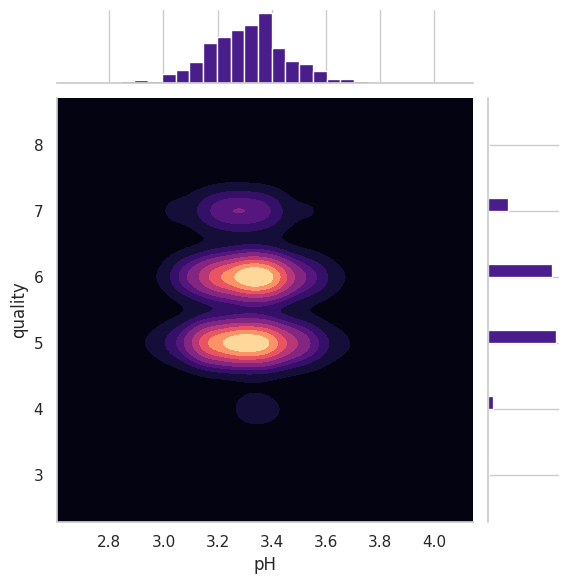

In [24]:
g = sns.JointGrid(data = df, x = "pH", y = "quality", space = 0.2)
g.plot_joint(sns.kdeplot, fill = True, thresh = 0, cmap = "magma")
g.plot_marginals(sns.histplot, color = "#491D8B", alpha = 1, bins = 25);

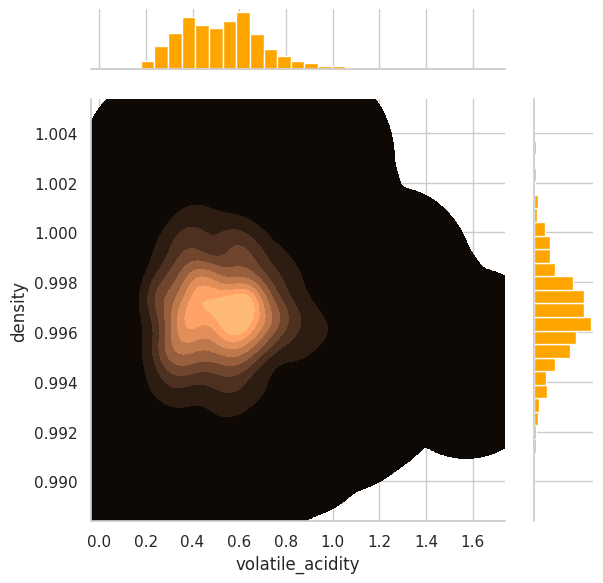

In [25]:
g = sns.JointGrid(data = df, x = "volatile_acidity", y = "density", space = 0.5)
g.plot_joint(sns.kdeplot, fill = True, thresh = 0, cmap = "copper")
g.plot_marginals(sns.histplot, color = "#FFA500", alpha = 1, bins = 25);

EDA 5. Regplot

<Axes: xlabel='total_sulfur_dioxide', ylabel='alcohol'>

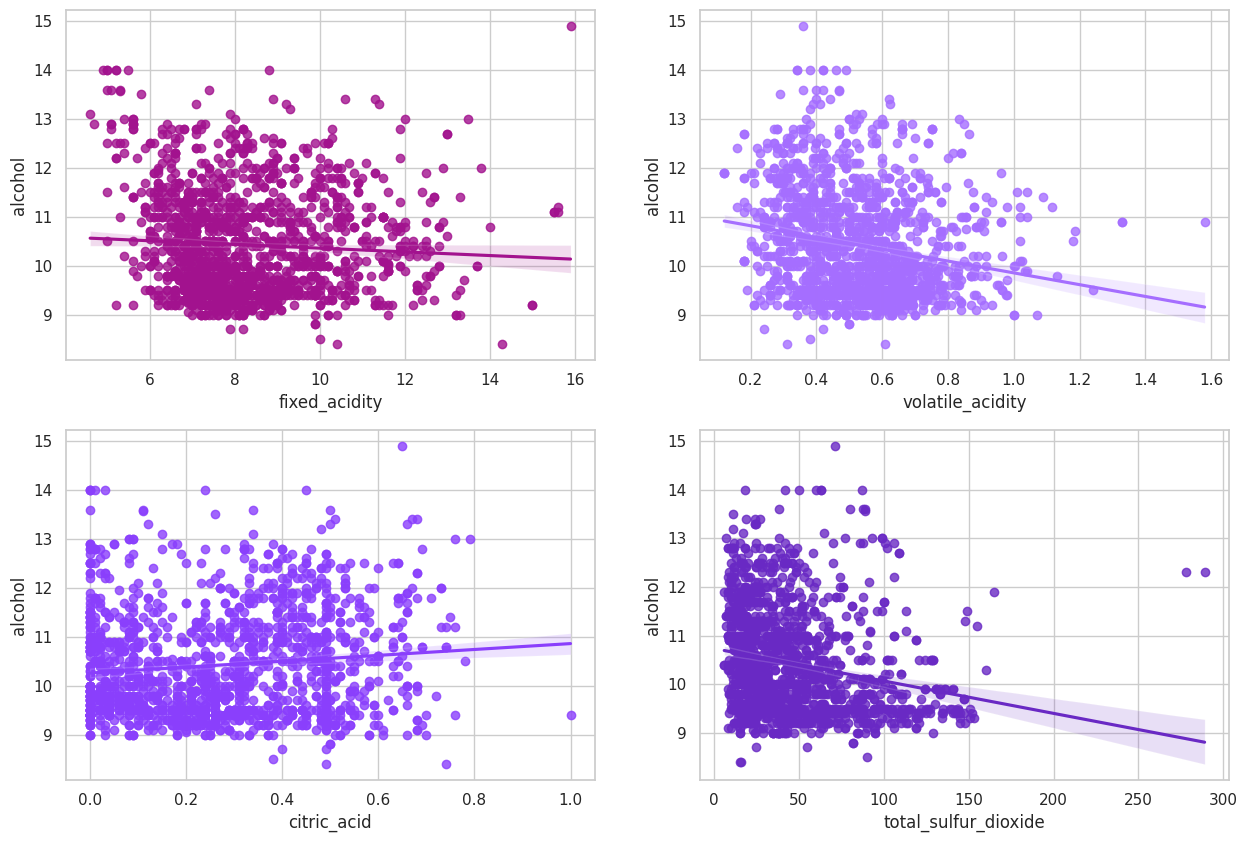

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.regplot(ax=axes[0], x="fixed_acidity", y="alcohol", data=df, color="#A2128E")
sns.regplot(ax=axes[1], x="volatile_acidity", y="alcohol", data=df, color="#A56EFF")
sns.regplot(ax=axes[2], x="citric_acid", y="alcohol", data=df, color="#8A3FFC")
sns.regplot(ax=axes[3], x="total_sulfur_dioxide", y="alcohol", data=df, color="#6929C4")

Attention to the negative linear relationships between the "alcohol" - "volatile acidity" and "alcohol" - "total_sulfur_dioxide" variables.

EDA 6. Hexagonal Binned Plot

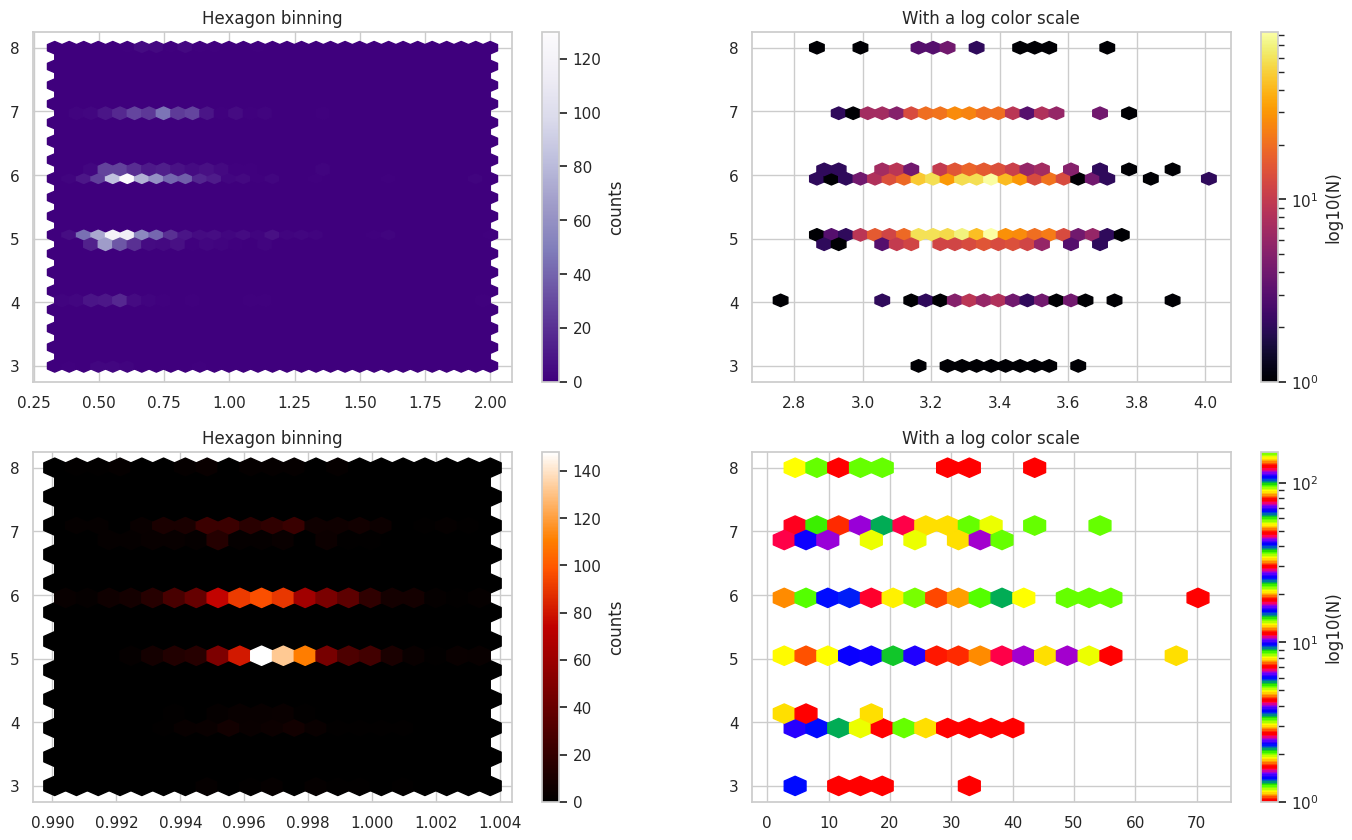

In [27]:
fig, ([ax0, ax1], [ax2, ax3]) = plt.subplots(nrows = 2, ncols = 2, figsize = (17, 10))

hb = ax0.hexbin(df["sulphates"], df["quality"], gridsize = 30, cmap = 'Purples_r')
ax0.set_title("Hexagon binning")
cb = fig.colorbar(hb, ax = ax0, label = 'counts')


hb = ax1.hexbin(df["pH"], df["quality"], gridsize = 30, bins = 'log', cmap = 'inferno')
ax1.set_title("With a log color scale")
cb = fig.colorbar(hb, ax = ax1, label = 'log10(N)')


hb = ax2.hexbin(df["density"], df["quality"], gridsize = 20, cmap = 'gist_heat')
ax2.set_title("Hexagon binning")
cb = fig.colorbar(hb, ax = ax2, label = 'counts')

hb = ax3.hexbin(df["free_sulfur_dioxide"], df["quality"], gridsize = 20, bins = 'log',
                cmap = 'prism')
ax3.set_title("With a log color scale")
cb = fig.colorbar(hb, ax = ax3, label = 'log10(N)')

plt.show()

EDA 7. Pyplot

In [28]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

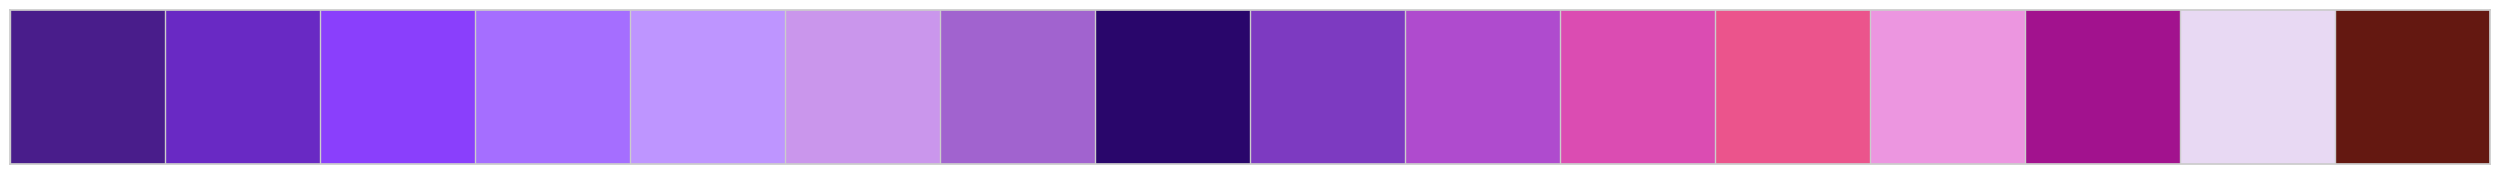

In [29]:
purple = ['#491D8B', '#6929C4', '#8A3FFC', '#A56EFF',
          '#BE95FF', '#CA96EC', '#A163CF', '#29066B',
          '#7D3AC1', '#AF4BCE', '#DB4CB2', '#EB548C',
          '#EC96E0', '#A2128E', '#E8D9F3', '#641811']

sns.palplot(purple, size = 2)

In [30]:
# fig = px.histogram(df, x="residual_sugar", y="quality", marginal="box", color=None, text_auto=True, hover_data=df.columns)
# fig.show()

In [31]:
fig = px.density_heatmap(df, x="pH", y="quality", z="residual_sugar", color_continuous_scale="magma", text_auto=True)
fig.show()

In [32]:
fig = px.density_heatmap(df, x = "density", y = "quality", z = "chlorides",
                        color_continuous_scale = "Viridis", text_auto = True)
fig.show()

In [33]:
fig = px.density_heatmap(df, x = "chlorides", y = "quality", text_auto = True,
                         color_continuous_scale = "sunsetdark")
fig.show()

In [34]:
data = df.copy()
fig = go.Figure(data = [go.Surface(z = data.values)])
fig.update_layout(autosize = True, width = 600, height = 600)

fig.show()

In [35]:
data = df[["residual_sugar", "density", "sulphates", "chlorides", "quality"]]

fig = go.Figure(data = [go.Surface(z = data.values)])
fig.update_layout(autosize = True, width = 600, height = 600)

fig.show()

In [36]:
subject = df["quality"]
score = df["alcohol"]

data = [dict(x = subject, y = score, mode = "markers", type = "scatter",
             transforms = [dict(type = "groupby", groups = subject)])]

fig_dict = dict(data = data)
pio.show(fig_dict, validate = False)

In [37]:
subject = df["quality"]
score = df["pH"]

data = [dict(x = subject, y = score, mode = "markers", type = "scatter",
             transforms = [dict(type = "groupby", groups = subject)])]

fig_dict = dict(data = data)
pio.show(fig_dict, validate = False)

In [38]:
subject = df["quality"]
score = df["chlorides"]

data = [dict(x = subject, y = score, mode = "markers", type = "scatter",
             transforms = [dict(type = "groupby", groups = subject)])]

fig_dict = dict(data = data)
pio.show(fig_dict, validate = False)

In [39]:
fig = px.ecdf(df, x = "alcohol", log_x = True, log_y = True, color = "quality")
fig.show()

In [40]:
fig = px.ecdf(df, x = "citric_acid", log_x = True, log_y = True, color = "quality")
fig.show()

In [41]:
fig = px.ecdf(df, x = ["pH", "sulphates", "alcohol"],
              marginal = "histogram", markers = False)
fig.show()

EDA 8. Heatmap and Correlation

In [42]:
plt.figure(figsize = [20, 10], facecolor = 'white')
# sns.heatmap(df.corr(), annot = True, linewidths = 2, cmap = "magma");
df.corr().style.background_gradient(cmap="magma")

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
fixed_acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile_acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric_acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual_sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free_sulfur_dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total_sulfur_dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<Figure size 2000x1000 with 0 Axes>

IMPORTANT NOTE! There is 'multicollinearity' problem

Here we see that there is relatively high (0.67, positive) correlation between 'free sulfur dioxide' and 'total_sulfur_dioxide' variables. There is relatively high (-0.68, negative) correlation between "pH" and "fixed_acidity" variables. And there is about 0.5 correlation between some of other variables. That's why we must consider when build Machine Learning models.  

| Variables                                  | Correlation |
| ------------------------------------------ | ----------: |
| fixed_acidity ↔ pH                         |  **-0.683** |
| fixed_acidity ↔ citric_acid                |   **0.672** |
| fixed_acidity ↔ density                    |   **0.668** |
| free_sulfur_dioxide ↔ total_sulfur_dioxide |   **0.668** |
| citric_acid ↔ pH                           |  **-0.541** |
| alcohol ↔ density                          |  **-0.496** |

In [43]:
from scipy.stats import pearsonr

pairs = [
    ("fixed_acidity", "pH"),
    ("fixed_acidity", "citric_acid"),
    ("fixed_acidity", "density"),
    ("free_sulfur_dioxide", "total_sulfur_dioxide"),
    ("citric_acid", "pH"),
    ("alcohol", "density"),
]

for col1, col2 in pairs:
    r, p = pearsonr(df[col1], df[col2])
    print(f"{col1:25} vs {col2:25} | r = {r:7.4f} | p = {p:.2e}")

fixed_acidity             vs pH                        | r = -0.6830 | p = 4.06e-220
fixed_acidity             vs citric_acid               | r =  0.6717 | p = 2.54e-210
fixed_acidity             vs density                   | r =  0.6680 | p = 3.07e-207
free_sulfur_dioxide       vs total_sulfur_dioxide      | r =  0.6677 | p = 6.40e-207
citric_acid               vs pH                        | r = -0.5419 | p = 1.01e-122
alcohol                   vs density                   | r = -0.4962 | p = 3.94e-100


## Data Preprocessing

In [44]:
df.head().style.background_gradient(cmap="Purples_r")

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,5
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,5
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,6
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5


In [45]:
df.quality.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

- High quality wine: 6 - 8
- Low quality wine: 3 - 5

In [46]:
# df.quality[df.quality <= 5] = 0
# df.quality[df.quality > 5] = 1

df["quality"] = np.where(df["quality"] > 5, 1, 0)

In [47]:
df.quality.value_counts()

quality
1    855
0    744
Name: count, dtype: int64

In [48]:
df.head().style.background_gradient(cmap="Reds")

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,0
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,0
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,1
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0


In [49]:
y = df["quality"]
x = df.drop(columns=["quality"], axis=1)

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=1)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1199, 11), (400, 11), (1199,), (400,))

But we will not use 'StandardScaler', because our dataset is not normally distributed. We will use 'MinMaxScaler' for normalizing this dataset. It transforms features by scaling each feature to a given range. This estimator scales and translates each feature individually such that it is in the given range on the training set, e.g. between 0 and 1.

In [51]:
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler(feature_range=(0, 1))
X_train = norm.fit_transform(X_train)
X_test = norm.transform(X_test)

## Building Machine Learning Models

In [52]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
# from sklearn.metrics import plot_confusion_matrix

In [53]:
# GridSearchCV?

### K Nearest Neighbor Algorithm

In [54]:
from sklearn.neighbors import KNeighborsClassifier

knn_params = {
    "n_neighbors": np.arange(2, 50),
    "weights": ["uniform", "distance"],
    "leaf_size": [25, 30, 25],
}

knn_cv_model = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=knn_params, scoring="accuracy", cv=10)
knn_cv_model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': [25, 30, 25],
                         'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [55]:
print("Best score for train set: " + str(knn_cv_model.best_score_))
print(knn_cv_model.best_estimator_)
print(knn_cv_model.best_params_)
print("____________________________________________")
print("best K value: " + str(knn_cv_model.best_params_["n_neighbors"]),
     "\nbest weights: " + knn_cv_model.best_params_["weights"],
     "\nbest leaf size: " + str(knn_cv_model.best_params_["leaf_size"]))

Best score for train set: 0.798172268907563
KNeighborsClassifier(leaf_size=25, n_neighbors=np.int64(21), weights='distance')
{'leaf_size': 25, 'n_neighbors': np.int64(21), 'weights': 'distance'}
____________________________________________
best K value: 21 
best weights: distance 
best leaf size: 25


In [56]:
knn_model = knn_cv_model.best_estimator_
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.8025

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       188
           1       0.82      0.80      0.81       212

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



### Gradient Boosting Algorithm

In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gbm_params = {
    "learning_rate": [0.005, 0.008, 0.1, 0.15],
    "n_estimators": [80, 100, 150, 200],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 3, 4]
}

gbm_cv_model = GridSearchCV(estimator=GradientBoostingClassifier(), param_grid=gbm_params, scoring="accuracy", cv=10, n_jobs=-1)
gbm_cv_model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.005, 0.008, 0.1, 0.15],
                         'max_depth': [2, 3, 4], 'min_samples_split': [2, 3, 4],
                         'n_estimators': [80, 100, 150, 200]},
             scoring='accuracy')

In [59]:
print("Best score for train set: " + str(gbm_cv_model.best_score_))
print(gbm_cv_model.best_estimator_)
print(gbm_cv_model.best_params_)
print("__________________________________________________________")
print("best learning_rate value: " + str(gbm_cv_model.best_params_["learning_rate"]),
     "\nbest n_estimators value: " + str(gbm_cv_model.best_params_["n_estimators"]),
     "\nbest max_depth value: " + str(gbm_cv_model.best_params_["max_depth"]),
     "\nbest min_samples_split value: " + str(gbm_cv_model.best_params_["min_samples_split"]))

Best score for train set: 0.8081722689075631
GradientBoostingClassifier(max_depth=4)
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
__________________________________________________________
best learning_rate value: 0.1 
best n_estimators value: 100 
best max_depth value: 4 
best min_samples_split value: 2


In [60]:
gbm_model = gbm_cv_model.best_estimator_
gbm_model.fit(X_train, y_train)

y_pred = gbm_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7975

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79       188
           1       0.83      0.78      0.80       212

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



### LightGBM Algorithm

In [62]:
# !pip install lightgbm
from lightgbm import LGBMClassifier

lgbm_params = {
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 150],
    "max_depth": [-1, 4],
    "min_child_samples": [20, 30]
}

lgbm_cv_model = GridSearchCV(estimator=LGBMClassifier(), param_grid=lgbm_params, scoring="accuracy", cv=10, n_jobs=-1)
lgbm_cv_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Number of positive: 579, number of negative: 500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 984
[LightGBM] [Info] Number of data points in the train set: 1079, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.536608 -> initscore=0.146694
[LightGBM] [Info] Start training from score 0.146694
[LightGBM] [Info] Number of positive: 579, number of negative: 500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 985
[LightGBM] [Info] Number of data points in the train set: 1079, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.536608 -> initscore=0.146694
[LightGBM] [Info] Start training from score 0.146694
[LightGBM] [Warning] No furt

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 579, number of negative: 500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 984
[LightGBM] [Info] Number of data points in the train set: 1079, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.536608 -> initscore=0.146694
[LightGBM] [Info] Start training from score 0.146694
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


GridSearchCV(cv=10, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [-1, 4],
                         'min_child_samples': [20, 30],
                         'n_estimators': [100, 150]},
             scoring='accuracy')

In [63]:
print("Best score for train set: " + str(lgbm_cv_model.best_score_))
print(lgbm_cv_model.best_estimator_)
print(lgbm_cv_model.best_params_)
print("____________________________________________")
print("best learning_rate value: " + str(lgbm_cv_model.best_params_["learning_rate"]),
     "\nbest n_estimators value: " + str(lgbm_cv_model.best_params_["n_estimators"]),
     "\nbest max_depth value: " + str(lgbm_cv_model.best_params_["max_depth"]),
     "\nbest min_child_samples value: " + str(lgbm_cv_model.best_params_["min_child_samples"]))

Best score for train set: 0.8065056022408964
LGBMClassifier(learning_rate=0.05)
{'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100}
____________________________________________
best learning_rate value: 0.05 
best n_estimators value: 100 
best max_depth value: -1 
best min_child_samples value: 20


In [64]:
lgbm_model = lgbm_cv_model.best_estimator_
lgbm_model.fit(X_train, y_train)

y_pred = lgbm_model.predict(X_test)
accuracy_score(y_test, y_pred)

[LightGBM] [Info] Number of positive: 643, number of negative: 556
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 1199, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.536280 -> initscore=0.145376
[LightGBM] [Info] Start training from score 0.145376


0.8125

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       188
           1       0.85      0.78      0.81       212

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



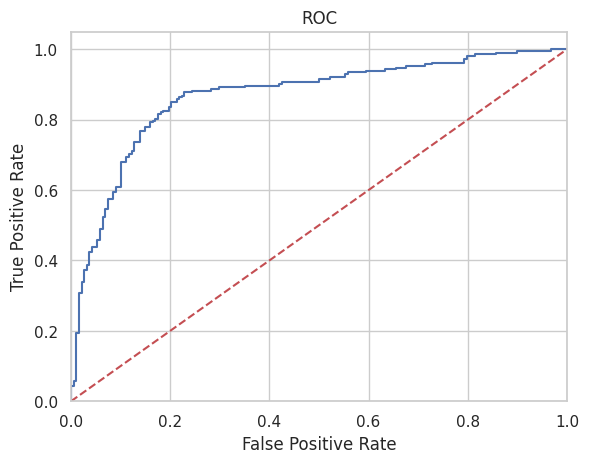

In [66]:
lgbm_roc_auc = roc_auc_score(y_test, lgbm_model.predict(X_test))

fpr, tpr, thresholds = roc_curve(y_test, lgbm_model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='AUC (area = %0.2f)' % lgbm_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()